# Black-Karasinki

We start from the Black–Karasinski dynamics given in the exercise:

$$
dlnS_{t} = \kappa \left( ln\theta - \frac{\sigma^2}{4\kappa} - lnS_{t} \right) dt + \sigma dW_t
$$

To simplify the derivation, we introduce the transformed process

$$
X_t=\ln S_t.
$$

The stochastic differential equation can then be rewritten as

$$
dX_t = 
\kappa
\left(
m-X_t
\right)dt
+
\sigma dW_t,
$$

where

$$
m=\ln\theta-\frac{\sigma^2}{4\kappa}.
$$

This is an Ornstein–Uhlenbeck process. We can therefore derive its exact transition between two consecutive simulation dates $t_n$ and $t_{n+1}$.

Let

$$
\Delta t=t_{n+1}-t_n.
$$

Using the integrating factor $e^{\kappa t}$, we obtain

$$
d(e^{\kappa t}X_t)=\kappa m e^{\kappa t}dt
+
\sigma e^{\kappa t}dW_t.
$$

Integrating between $t_n$ and $t_{n+1}$ gives

$$
e^{\kappa t_{n+1}}X_{t_{n+1}}= X_{t_n} + \kappa m \int_{t_n}^{t_{n+1}} e^{\kappa s}ds
+
\sigma \int_{t_n}^{t_{n+1}} e^{\kappa s}dW_s.
$$

After dividing by $e^{\kappa t_{n+1}}$ and simplifying the deterministic integral, we obtain

$$
X_{t_{n+1}}= e^{-\kappa t_{n+1}}X_{t_n} + \kappa m \int_{t_n}^{t_{n+1}} e^{-\kappa (t_{n+1}-s)}ds
+
\sigma \int_{t_n}^{t_{n+1}} e^{-\kappa (t_{n+1}-s)}dW_s.
$$


The remaining stochastic integral is normally distributed with zero mean. Its variance is given by

$$
\frac{\sigma^2}{2\kappa}
\left(
1-e^{-2\kappa\Delta t}
\right)
$$

It can therefore be represented using a standard normal random variable $Z_n\sim\mathcal N(0,1)$:

Substituting this result into the previous expression gives the exact transition of the logarithm of the spread:

$$
X_{t_{n+1}} = 
X_{t_n}e^{-\kappa\Delta t}
+
\left(
\ln\theta-\frac{\sigma^2}{4\kappa}
\right)
\left(1-e^{-\kappa\Delta t}\right)
+
\sigma
\sqrt{
\frac{1-e^{-2\kappa\Delta t}}{2\kappa}
}
Z_n

$$

Finally, since $X_t=\ln S_t$, the spread itself is obtained by exponentiating the previous expression:

$$
\boxed{
S_{t_{n+1}}=e^{X_{t_{n+1}}}.
}
$$

This exact transition equation provides the recursive relation required for the Monte Carlo simulation. At each time step, the next spread level is obtained from the current spread, the model parameters, the time step $\Delta t$, and a new independent standard normal draw $Z_n$.

Since we have a closed-form exact transition for the process, no numerical discretization scheme is required. We can therefore use NumPy to generate standard normal random variables and recursively simulate the spread at each time step from the previous simulated value.

## Simulation
We now perform a Monte Carlo simulation of the Black–Karasinski model. The model parameters $\kappa$, $\theta$, and $\sigma$ are assumed to be given, as specified in the exercise, and will be fixed throughout the simulation. Using the exact transition derived above, we recursively simulate the spread paths for a given number of underlying names and time steps.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Model parameters
kappa = 0.5
theta = 0.02
sigma = 0.20
X_0=np.log(0.02)

# Simulation parameters
n_names = 50
n_steps = 100
n_simulations = 100
T=1.0

# Time step
dt = T / n_steps

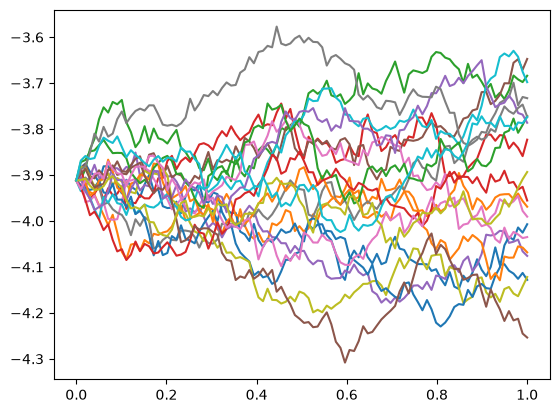

In [49]:
Id = np.eye(n_names)
decay = np.exp(-kappa*dt)
m=np.log(theta)-sigma**2/(4*kappa)
X=np.zeros((n_names,n_steps))
X[:,0]=np.log(0.02)
for i in range(0,n_steps-1):
    Z=np.random.multivariate_normal(np.zeros((n_names)),Id)
    X[:,i+1]=X[:,i]*decay + m*(1-decay)+sigma*np.sqrt((1-decay**2)/(2*kappa))*Z

x=np.linspace(0,T,n_steps)
for i in range(n_names):
    plt.plot(x,X[i,:])

plt.show()

The simulated spread paths are now used to re-estimate the volatility parameter. Following the simplifying assumption specified in the exercise, we treat the simulated spread returns as Brownian-motion returns and assume that the same volatility parameter applies to all underlying names.

For each underlying name and each time step, we first compute the logarithmic return:

$$
r_{i,n} = 
\ln\left(
\frac{S_{i,t_{n+1}}}{S_{i,t_n}}
\right).
$$

We then pool the returns across all underlying names and time steps and estimate their variance. Since the variance of a Brownian increment over a time interval $\Delta t$ is $\sigma^2\Delta t$, the volatility can be recovered as

$$
\hat{\sigma} = 
\sqrt{
\frac{\widehat{\operatorname{Var}}(r)}
{\Delta t}
}.
$$

This gives a single re-estimated volatility $\hat{\sigma}$ for the whole population, which will then be used in the next step to assess the uncertainty of the original volatility calibration.

Since the $(r_{i,n})_{i,n}$ are assumed to be independent and iid across underlying names and time steps, all simulated returns can be pooled together to estimate a common mean. The empirical mean is therefore given by

$$
\bar r
=
\frac{1}{N}
\sum_{i=1}^{N_{\mathrm{names}}}
\sum_{n=1}^{N_{\mathrm{steps}}-1}
r_{i,n},
$$

where

$$
N=N_{\mathrm{names}}\left(N_{\mathrm{steps}}-1\right).
$$

Under the Brownian-motion assumption, the theoretical mean of each return is zero, so we expect $\bar r$ to be close to zero. This common pool of independent returns is then used to estimate their empirical variance and, consequently, the volatility parameter $\hat{\sigma}$.

In [50]:
r=X[:,1:]-X[:,:-1]

est_sigma=np.sqrt(r.var()/dt)

print(est_sigma)

0.20373726826129257


The estimated volatility is $\hat{\sigma}$, which is very close to the initial value of $0.20$. This confirms that the estimation procedure is able to recover the original volatility parameter with good accuracy.

### Assessment of Calibration Uncertainty

The simulation and volatility re-estimation steps are now encapsulated in a single function. We can therefore reuse this function to assess how the estimated volatility varies under different configurations.

In [51]:
def black_karasinki_log_return_simu (nb_names,nb_steps,T,X_0,kappa,theta,sigma):
    dt = T / nb_steps
    disc = np.exp(-kappa*dt)
    l=np.log(theta)-sigma**2/(4*kappa)
    X=np.zeros((nb_names,nb_steps))
    X[:,0]=X_0
    for i in range(0,nb_steps-1):
        Z=np.random.normal(size=nb_names)
        X[:,i+1]=X[:,i]*disc + l*(1-disc)+sigma*np.sqrt((1-disc**2)/(2*kappa))*Z

    lr=X[:,1:]-X[:,:-1]
    est_sigma=np.sqrt(lr.var()/dt)
    return est_sigma
    

 We start by varying the number of underlying names, while keeping the other parameters fixed.
 

In [ ]:
Names = [2,10,100,1000,10000]
est_sigma=[]
est_sigma_vect=[]

for names in Names:
    for i in range(n_simulations):
        est_sigma_vect.append(float(black_karasinki_log_return_simu (names,n_steps,T,X_0,kappa,theta,sigma)))
    est_sigma.append(est_sigma_vect)
    est_sigma_vect=[]


In [63]:
var=[]
sig=[]
for i in range(len(Names)):
    var.append(np.var(est_sigma[i]))
    sig.append(np.mean(est_sigma[i]))
    sig[i]=float(sig[i])

res=pd.DataFrame({
            "Number of Names":Names,
            "Estimated Volatility" : sig,
            "Estimator Variance" : var
})

res

,Number of Names,Estimated Volatility,Estimator Variance
0,2,0.198106,9.215086e-05
1,10,0.198926,1.604218e-05
2,100,0.199492,1.903291e-06
3,1000,0.199468,1.918758e-07
4,10000,0.199589,1.956690e-08


### Variance of the Log-Spread Returns

We define

$$
X_t = \ln S_t
$$

so that the Black--Karasinski dynamics become

$$
dX_t
=
\kappa(m-X_t)\,dt+\sigma\,dW_t,
$$

with

$$
m
=
\ln\theta-\frac{\sigma^2}{4\kappa}.
$$


For a time step $\Delta t$, the exact solution is

$$
X_{t_{n+1}}
=
m
+
(X_{t_n}-m)e^{-\kappa\Delta t}
+
\sigma
\sqrt{
\frac{1-e^{-2\kappa\Delta t}}{2\kappa}
}
Z_n,
$$

where $Z_n\sim\mathcal{N}(0,1)$.

We define the logarithmic return as

$$
R_n
=
X_{t_{n+1}}-X_{t_n}.
$$

Therefore,

$$
R_n
=
(e^{-\kappa\Delta t}-1)(X_{t_n}-m)
+
\sigma
\sqrt{
\frac{1-e^{-2\kappa\Delta t}}{2\kappa}
}
Z_n.
$$


Since the simulation starts from a fixed value $X_0$, the solution from $X_0$ is

$$
X_t
=
m
+
(X_0-m)e^{-\kappa t}
+
\sigma
\int_0^t e^{-\kappa(t-s)}\,dW_s.
$$

The first two terms are deterministic, so only the stochastic integral contributes to the variance:

$$
\operatorname{Var}(X_t)
=
\sigma^2
\int_0^t e^{-2\kappa(t-s)}\,ds.
$$

Evaluating the integral gives

$$
\operatorname{Var}(X_t)
=
\frac{\sigma^2}{2\kappa}
\left(1-e^{-2\kappa t}\right).
$$

Hence,

$$
\boxed{
\operatorname{Var}(X_{t_n})
=
\frac{\sigma^2}{2\kappa}
\left(1-e^{-2\kappa t_n}\right)
}
$$


From the expression for $R_n$,

$$
R_n
=
(e^{-\kappa\Delta t}-1)(X_{t_n}-m)
+
\sigma
\sqrt{
\frac{1-e^{-2\kappa\Delta t}}{2\kappa}
}
Z_n.
$$

The two random terms are independent, since $X_{t_n}$ depends on the Brownian shocks up to $t_n$, whereas $Z_n$ represents the new shock over $[t_n,t_{n+1}]$.

Therefore,

$$
\operatorname{Var}(R_n)
=
(e^{-\kappa\Delta t}-1)^2
\operatorname{Var}(X_{t_n})
+
\sigma^2
\frac{1-e^{-2\kappa\Delta t}}{2\kappa}.
$$

Substituting the expression for $\operatorname{Var}(X_{t_n})$ gives

$$
\operatorname{Var}(R_n)
=
\frac{\sigma^2}{2\kappa}
\left[
(e^{-\kappa\Delta t}-1)^2
(1-e^{-2\kappa t_n})
+
1-e^{-2\kappa\Delta t}
\right].
$$

Since

$$
(e^{-\kappa\Delta t}-1)^2
=
(1-e^{-\kappa\Delta t})^2,
$$

we obtain

$$
\boxed{
\operatorname{Var}(R_n)
=
\frac{\sigma^2}{2\kappa}
\left[
(1-e^{-\kappa\Delta t})^2
(1-e^{-2\kappa t_n})
+
1-e^{-2\kappa\Delta t}
\right]
}
$$


To simplify the expression, let

$$
a=e^{-\kappa\Delta t}.
$$

Then

$$
\operatorname{Var}(R_n)
=
\frac{\sigma^2}{2\kappa}
\left[
(1-a)^2(1-e^{-2\kappa t_n})
+
1-a^2
\right].
$$

Expanding the expression inside the brackets,

$$
(1-a)^2(1-e^{-2\kappa t_n})
+
1-a^2
$$

$$
=
(1-2a+a^2)
-
(1-2a+a^2)e^{-2\kappa t_n}
+
1-a^2
$$

and therefore

$$
=
2-2a
-
(1-a)^2e^{-2\kappa t_n}.
$$

Hence,

$$
\boxed{
\operatorname{Var}(R_n)
=
\frac{\sigma^2}{2\kappa}
\left[
2(1-e^{-\kappa\Delta t})
-
(1-e^{-\kappa\Delta t})^2e^{-2\kappa t_n}
\right]
}
$$

In particular,

$$
\operatorname{Var}(R_n)
<
\frac{\sigma^2}{\kappa}
(1-e^{-\kappa\Delta t}),
$$

because the second term inside the brackets is positive.

Furthermore, for $x>0$,

$$
1-e^{-x}<x.
$$

Taking $x=\kappa\Delta t$ gives

$$
\frac{\sigma^2}{\kappa}
(1-e^{-\kappa\Delta t})
<
\sigma^2\Delta t.
$$

Therefore,

$$
\boxed{
\operatorname{Var}(R_n)<\sigma^2\Delta t
}
$$


In the exercise, the volatility is estimated under the simplifying assumption that the log-spread returns behave as Brownian-motion increments:

$$
\hat{\sigma}
=
\sqrt{
\frac{\widehat{\operatorname{Var}}(R)}
{\Delta t}
}.
$$

If the actual variance of the Black--Karasinski log-spread returns is smaller than $\sigma^2\Delta t$, then this estimator will tend to produce an estimate below the true model parameter:

$$
\boxed{
\hat{\sigma}<\sigma.
}
$$

This provides an explanation for the small downward deviation observed in the simulations, where the true volatility is $\sigma=20\%$ while the estimated volatility is typically slightly below $20\%$.

The key point is that the log-spread returns are not pure Brownian increments. They also contain the mean-reversion component, which affects their variance.

We now study the sensitivity of the volatility estimator to the maturity $T$, while keeping the other parameters fixed.

In [65]:
Times = [1,2,10,100,1000]
est_sigma=[]
est_sigma_vect=[]

for t in Times:
    for i in range(n_simulations):
        est_sigma_vect.append(float(black_karasinki_log_return_simu (n_names,n_steps,t,X_0,kappa,theta,sigma)))
    est_sigma.append(est_sigma_vect)
    est_sigma_vect=[]

var=[]
sig=[]
for i in range(len(Times)):
    var.append(np.var(est_sigma[i]))
    sig.append(np.mean(est_sigma[i]))
    sig[i]=float(sig[i])

res=pd.DataFrame({
            "Maturity":Times,
            "Estimated Volatility" : sig,
            "Estimator Variance" : var
})

res

,Maturity,Estimated Volatility,Estimator Variance
0,1,0.199476,0.000011
1,2,0.199410,0.000009
2,10,0.196653,0.000007
3,100,0.177351,0.000008
4,1000,0.088887,0.000003


The estimated volatility decreases significantly as maturity increases. This effect becomes particularly pronounced for large maturities, where keeping the number of time steps fixed leads to increasingly large time increments $\Delta t$. The Brownian-motion approximation used for the volatility re-estimation therefore becomes less representative of the exact mean-reverting dynamics.

We now examine the sensitivity of the volatility estimator to the mean-reversion parameter $\kappa$, while keeping all other parameters fixed.

In [67]:
Kappa = [0.1,0.25,0.5,1,2]
est_sigma=[]
est_sigma_vect=[]

for k in Kappa:
    for i in range(n_simulations):
        est_sigma_vect.append(float(black_karasinki_log_return_simu (n_names,n_steps,T,X_0,k,theta,sigma)))
    est_sigma.append(est_sigma_vect)
    est_sigma_vect=[]

var=[]
sig=[]
for i in range(len(Kappa)):
    var.append(np.var(est_sigma[i]))
    sig.append(np.mean(est_sigma[i]))
    sig[i]=float(sig[i])

res=pd.DataFrame({
            "kappa":Kappa,
            "Estimated Volatility" : sig,
            "Estimator Variance" : var
})

res

,kappa,Estimated Volatility,Estimator Variance
0,0.10,0.199699,0.000012
1,0.25,0.199650,0.000012
2,0.50,0.199236,0.000015
3,1.00,0.199244,0.000011
4,2.00,0.198284,0.000012


The results show that the volatility estimator is relatively insensitive to the mean-reversion parameter $\kappa$ over the range considered. The estimated volatility remains close to the true value of 20\%, with only a slight downward trend as the mean-reversion speed increases.

We now examine the sensitivity of the volatility estimator to the long-term mean credit spread parameter $\theta$ while keeping all other parameters fixed.

In [71]:
Theta = [0.005,0.01,0.02,0.05,0.5]
est_sigma=[]
est_sigma_vect=[]

for O in Theta:
    for i in range(n_simulations):
        est_sigma_vect.append(float(black_karasinki_log_return_simu (n_names,n_steps,T,X_0,k,O,sigma)))
    est_sigma.append(est_sigma_vect)
    est_sigma_vect=[]

var=[]
sig=[]
for i in range(len(Theta)):
    var.append(np.var(est_sigma[i]))
    sig.append(np.mean(est_sigma[i]))
    sig[i]=float(sig[i])

res=pd.DataFrame({
            "Theta":Theta,
            "Estimated Volatility" : sig,
            "Estimator Variance" : var
})

res

,Theta,Estimated Volatility,Estimator Variance
0,0.005,0.210210,0.000012
1,0.010,0.201739,0.000012
2,0.020,0.198839,0.000011
3,0.050,0.203251,0.000011
4,0.500,0.251649,0.000010


The results show that varying $\theta$ has a limited impact on the estimated volatility, which remains relatively close to the true value of 20\%, although slightly larger deviations appear for extreme values of $\theta$.